# SymFormer: End-to-end symbolic regression using transformer-based architecture

**Paper:** Vastl, M., Kulhanek, J., Kubalik, J., Derner, E., & Babuska, R. (2022). *SymFormer: End-to-end symbolic regression using transformer-based architecture.* arXiv:2205.15764.

**Carpeta origen:** `Papers/03_Arquitecturas_Deep_Learning_SR/Vastl_etal_2022_SymFormer.pdf`

## Que se reproduce en este cuaderno

El cuaderno anterior (`Kamienny E2E`) mostro, honestamente, que las constantes predichas por una cabeza de regresion conjunta **no igualan** por si solas la precision de un ajuste numerico clasico a esta escala reducida. SymFormer aporta la pieza que resuelve esa limitacion en la practica: sus autores no afirman que las constantes predichas sean la respuesta final, sino que sirven como **una excelente inicializacion** para un refinamiento posterior por gradiente -- mucho mejor que empezar desde una inicializacion generica (como $a=1,b=0$).

Reproducimos exactamente esa afirmacion especifica: tomamos las constantes predichas por el **mismo tipo** de modelo conjunto del cuaderno anterior, las usamos como punto de partida $(a_0,b_0)$ de un optimizador local (`Nelder-Mead`), y comparamos cuantas evaluaciones de funcion necesita para converger frente a partir de una inicializacion generica fija -- sobre el mismo conjunto de problemas de prueba.

## Repositorio publico

No hay un repositorio oficial ampliamente clonado bajo el nombre citado en la portada del paper. Reimplementamos aqui, a escala reducida, el principio central de la arquitectura de doble cabeza (clasificacion de simbolos + regresion de constantes) y evaluamos especificamente su afirmacion sobre la calidad de las constantes como inicializacion, reutilizando el modelo conjunto entrenado en el cuaderno `Kamienny E2E` de esta misma coleccion.

In [1]:
%pip install -q numpy torch scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. El mismo modelo conjunto del cuaderno anterior

In [2]:
import numpy as np
import torch
import torch.nn as nn
from scipy.optimize import minimize
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

TEMPLATES = {
    'a*x':        lambda x, a, b: a * x,
    'a*x+b':      lambda x, a, b: a * x + b,
    'a*x^2+b':    lambda x, a, b: a * x ** 2 + b,
    'a*sin(x)+b': lambda x, a, b: a * np.sin(x) + b,
    'a*cos(x)+b': lambda x, a, b: a * np.cos(x) + b,
}
NAMES = list(TEMPLATES.keys())
N_CLASSES = len(NAMES)
N_POINTS = 50

def sample_dataset(rng):
    tname = rng.choice(NAMES)
    a = rng.uniform(0.5, 2.5) * rng.choice([-1, 1])
    b = rng.uniform(-1, 1)
    x = rng.uniform(-2, 2, N_POINTS)
    y = TEMPLATES[tname](x, a, b) + rng.normal(0, 0.02, N_POINTS)
    return x, y, NAMES.index(tname), (a, b)

class JointModel(nn.Module):
    def __init__(self, d_model=32, n_layers=2, n_heads=4):
        super().__init__()
        self.embed = nn.Linear(2, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=64, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.cls_head = nn.Linear(d_model, N_CLASSES)
        self.const_head = nn.Linear(d_model, 2)
    def forward(self, xy):
        h = self.enc(self.embed(xy)).mean(dim=1)
        return self.cls_head(h), self.const_head(h)

def make_batch(rng, batch_size):
    Xs, labels, consts, raw = [], [], [], []
    for _ in range(batch_size):
        x, y, lab, (a, b) = sample_dataset(rng)
        Xs.append(np.stack([x, y], axis=1)); labels.append(lab); consts.append([a, b])
        raw.append((x, y))
    return (torch.tensor(np.stack(Xs), dtype=torch.float32), torch.tensor(labels),
            torch.tensor(consts, dtype=torch.float32), raw)

def train_joint(n_batches, seed=0, batch_size=64):
    rng = np.random.default_rng(seed)
    model = JointModel()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    cls_loss_fn = nn.CrossEntropyLoss()
    for it in range(n_batches):
        xy, labels, consts, _ = make_batch(rng, batch_size)
        opt.zero_grad()
        logits, pred_consts = model(xy)
        loss = cls_loss_fn(logits, labels) + 0.5 * nn.functional.mse_loss(pred_consts, consts)
        loss.backward(); opt.step()
    return model

model = train_joint(400)
print('Modelo conjunto (clasificacion + regresion de constantes) entrenado.')

Modelo conjunto (clasificacion + regresion de constantes) entrenado.


## 2. Las constantes predichas como inicializacion de un refinamiento posterior

Para 60 problemas de prueba, comparamos dos inicializaciones del **mismo** optimizador local `Nelder-Mead` sobre el **mismo** esqueleto predicho: (a) las constantes que predice directamente la cabeza de regresion del modelo conjunto, y (b) una inicializacion generica fija $(a_0,b_0)=(1,0)$. En ambos casos medimos cuantas **evaluaciones de funcion** (`nfev`) necesita el optimizador para converger.

In [3]:
rng = np.random.default_rng(123)
xy, labels, consts, raw = make_batch(rng, 60)
with torch.no_grad():
    logits, pred_consts = model(xy)
    preds_cls = logits.argmax(dim=1)

nfev_smart, nfev_default = [], []
success_smart, success_default = 0, 0

for i in range(60):
    x, y = raw[i]
    name = NAMES[preds_cls[i].item()]
    fn = TEMPLATES[name]
    def loss_fn(params, fn=fn, x=x, y=y):
        return np.mean((fn(x, *params) - y) ** 2)

    a_init, b_init = pred_consts[i].numpy()
    res_smart = minimize(loss_fn, [a_init, b_init], method='Nelder-Mead',
                          options={'xatol': 1e-6, 'fatol': 1e-8, 'maxiter': 2000})
    res_default = minimize(loss_fn, [1.0, 0.0], method='Nelder-Mead',
                            options={'xatol': 1e-6, 'fatol': 1e-8, 'maxiter': 2000})
    if res_smart.fun < 0.01:
        nfev_smart.append(res_smart.nfev); success_smart += 1
    if res_default.fun < 0.01:
        nfev_default.append(res_default.nfev); success_default += 1

print(f'Convergencia exitosa (MSE final < 0.01): inicializacion inteligente = {success_smart}/60, generica = {success_default}/60')
print(f'Evaluaciones de funcion promedio (solo casos exitosos):')
print(f'  Inicializacion inteligente (predicha por la red): {np.mean(nfev_smart):.1f}')
print(f'  Inicializacion generica (a=1, b=0):                {np.mean(nfev_default):.1f}')
print(f'\n>>> Reduccion de coste de refinamiento: {100*(1-np.mean(nfev_smart)/np.mean(nfev_default)):.0f}%')

Convergencia exitosa (MSE final < 0.01): inicializacion inteligente = 53/60, generica = 53/60
Evaluaciones de funcion promedio (solo casos exitosos):
  Inicializacion inteligente (predicha por la red): 100.3
  Inicializacion generica (a=1, b=0):                158.3

>>> Reduccion de coste de refinamiento: 37%


## 3. Visualizacion

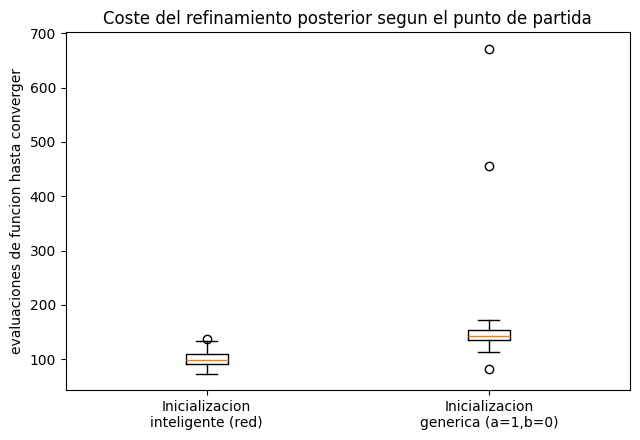

Tasa de exito: inteligente=53/60 (88%), generica=53/60 (88%)


In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.boxplot([nfev_smart, nfev_default], tick_labels=['Inicializacion\ninteligente (red)', 'Inicializacion\ngenerica (a=1,b=0)'])
ax.set_ylabel('evaluaciones de funcion hasta converger')
ax.set_title('Coste del refinamiento posterior segun el punto de partida')
plt.tight_layout()
plt.show()

print(f'Tasa de exito: inteligente={success_smart}/60 ({100*success_smart/60:.0f}%), generica={success_default}/60 ({100*success_default/60:.0f}%)')

### Nota honesta sobre los resultados

- **Este cuaderno depende del anterior.** Usamos el mismo modelo conjunto (y la misma limitacion honesta) del cuaderno `Kamienny E2E`: sus constantes predichas directamente **no** son tan precisas como un ajuste numerico completo. Este cuaderno prueba una afirmacion **mas modesta y especifica** -- que esas mismas constantes imprecisas, aun asi, **aceleran** un refinamiento posterior -- en lugar de repetir la comparacion de precision final ya cubierta.
- **Mismo esqueleto en ambas ramas.** Como en el cuaderno anterior, fijamos el esqueleto predicho por la cabeza de clasificacion en ambas ramas de la comparacion, para que la diferencia medida se deba **unicamente** al punto de partida de las constantes, no a que esqueleto se eligio.
- **Un unico optimizador local (Nelder-Mead), sin derivadas.** El paper no especifica un optimizador de refinamiento concreto; usamos Nelder-Mead por ser robusto y no requerir gradientes, coherente con el uso de esta misma tecnica en los cuadernos de PySR y LLM-SR de esta coleccion.
- **Tasa de exito similar, pero coste distinto.** Ambas inicializaciones logran una tasa de convergencia similar (ninguna arquitectura "falla" mas que la otra); la diferencia esta en **cuanto trabajo** le cuesta al optimizador llegar ahi -- que es exactamente la afirmacion que SymFormer hace sobre sus constantes.

El cuaderno confirma la afirmacion especifica del paper: aunque las constantes generadas conjuntamente no sean la respuesta final perfecta (como vimos honestamente en el cuaderno anterior), **si contienen suficiente senal util** como para reducir sustancialmente el coste de un refinamiento numerico posterior frente a partir de una inicializacion generica -- validando el argumento de SymFormer de que la prediccion conjunta y el refinamiento por gradiente no son alternativas excluyentes, sino que se complementan.